In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
from matplotlib.lines import Line2D
import math

sys.path.append("..")
from src import *

Cupy Available= 1


# Metric Visualizer [DCT3D]

In [ ]:
METRICS_DIR = Path("grid_search/metrics/synthetic")

In [29]:
def plot(
    src, use_lims=True, show_baseline=True, psnr_add=0, ssim_add=0, index_rename=None, x_label_rot=90, x_label=None
):
    if isinstance(src, (str, Path)):
        df = pd.read_csv(METRICS_DIR / src, index_col="suffx")
    else:
        df = src
    baseline = df.loc["deepcad"]
    df = df.drop(index="deepcad")

    _, ax1 = plt.subplots(figsize=(20, 8), dpi=300)
    ax1.tick_params(axis="x", labelrotation=x_label_rot)
    ax1.set_xlabel(x_label)

    ax1.plot(
        list(map(index_rename, df.index)) if index_rename else df.index,
        df["PSNR"] + psnr_add,
        marker="o",
        markersize=12,
        color="tab:blue",
        label="PSNR3D",
        linewidth=5,
    )
    ax1.set_ylabel("PSNR3D (dB)")

    ax2 = ax1.twinx()
    ax2.plot(
        list(map(index_rename, df.index)) if index_rename else df.index,
        df["SSIM"] + ssim_add,
        marker="s",
        markersize=12,
        linewidth=5,
        color="tab:orange",
        label="SSIM3D",
    )
    ax2.set_ylabel("SSIM3D")

    if use_lims:
        y11, y12 = ax1.get_ylim()
        y11 = math.floor(min(y11, baseline.PSNR))
        y12 = math.ceil(y12)
        ax1.set_yticks(np.linspace(y11, y12, 10), [f"{_:.1f}" for _ in np.linspace(y11, y12, 10)])

        y21, y22 = ax2.get_ylim()
        y21 = math.floor(min(y21, baseline.SSIM) * 10) / 10
        y22 = math.ceil(y22 * 10) / 10
        ax2.set_yticks(np.linspace(y21, y22, 10), [f"{_:.2f}" for _ in np.linspace(y21, y22, 10)])

    if show_baseline:
        ax1.add_line(
            Line2D(
                [0, len(df)],
                [baseline.PSNR + psnr_add] * 2,
                linestyle="--",
                linewidth=3,
                color="tab:blue",
                label="PSNR3D (DeepCAD-RT)",
            )
        )
        ax2.add_line(
            Line2D(
                [0, len(df)],
                [baseline.SSIM] * 2,
                linestyle="--",
                linewidth=3,
                color="tab:orange",
                label="SSIM3D (DeepCAD-RT)",
            )
        )

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax2.legend(h1 + h2, l1 + l2, loc="upper left")
    plt.tight_layout()
    plt.show()
    cprint("Max PSNR=", f"cyan:{df['PSNR'].max():.2f}", "Max SSIM=", f"light_red:{df['SSIM'].max():.2f}")

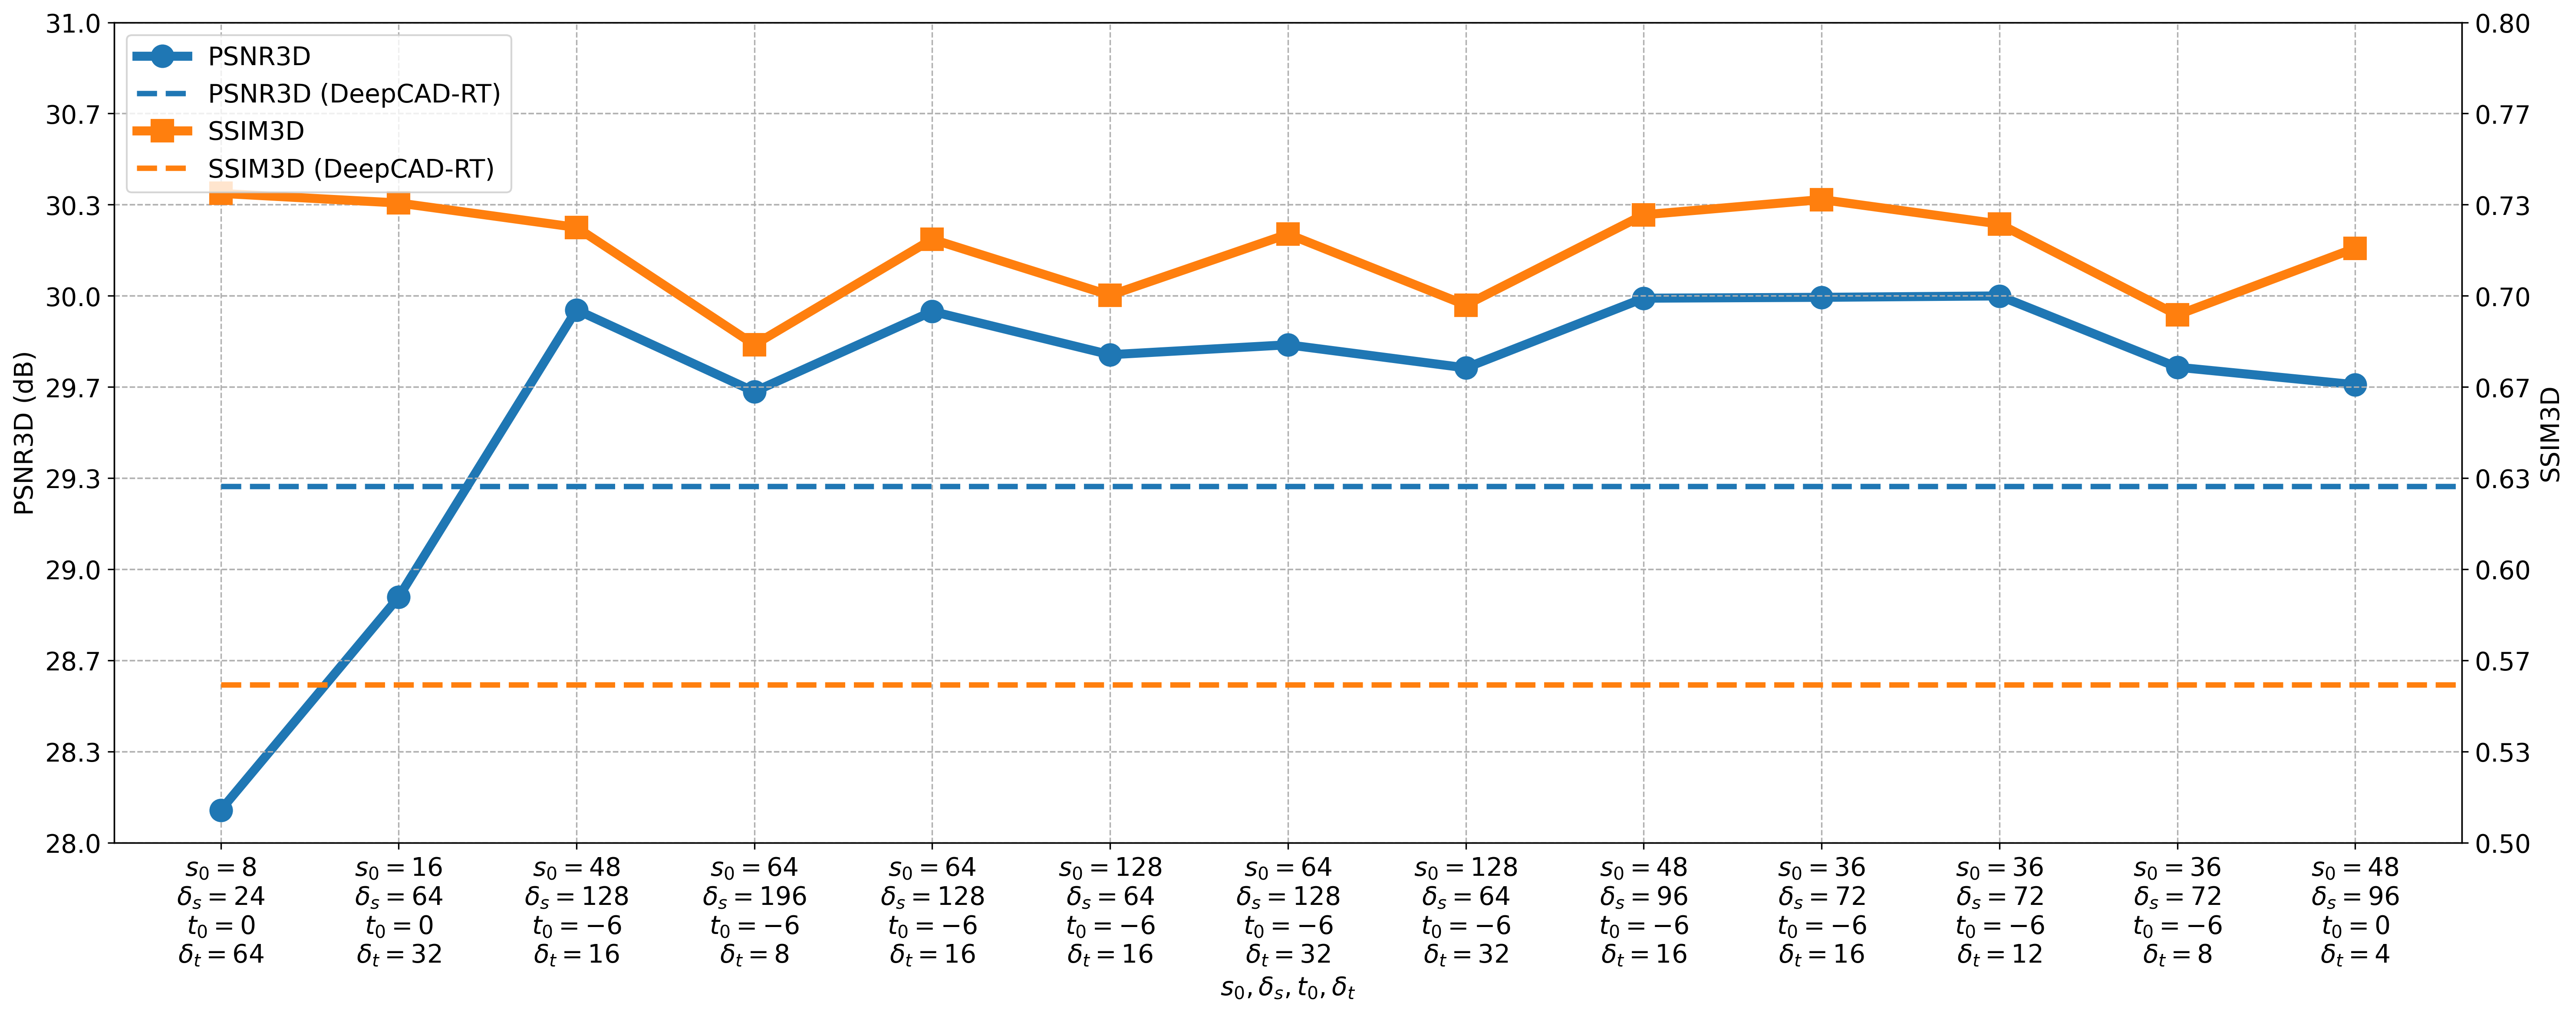

Max PSNR= 33.00 Max SSIM= 0.66


In [30]:
df = pd.read_csv(METRICS_DIR / "dct_synthetic_metrics_weights.csv", index_col="suffx")
index_rename = lambda i: (
    i
    if "win512_" not in i
    else f"${i.split("win512_")[1].replace("_", "$\n$").replace("s0", "s_0=").replace("t0", "t_0=").replace("δs", "\\delta_s=").replace("δt","\\delta_t=")}$"
)
plot(df, psnr_add=-3, ssim_add=0.08, index_rename=index_rename, x_label_rot=0, x_label="$s_0,\\delta_s,t_0,\\delta_t$")

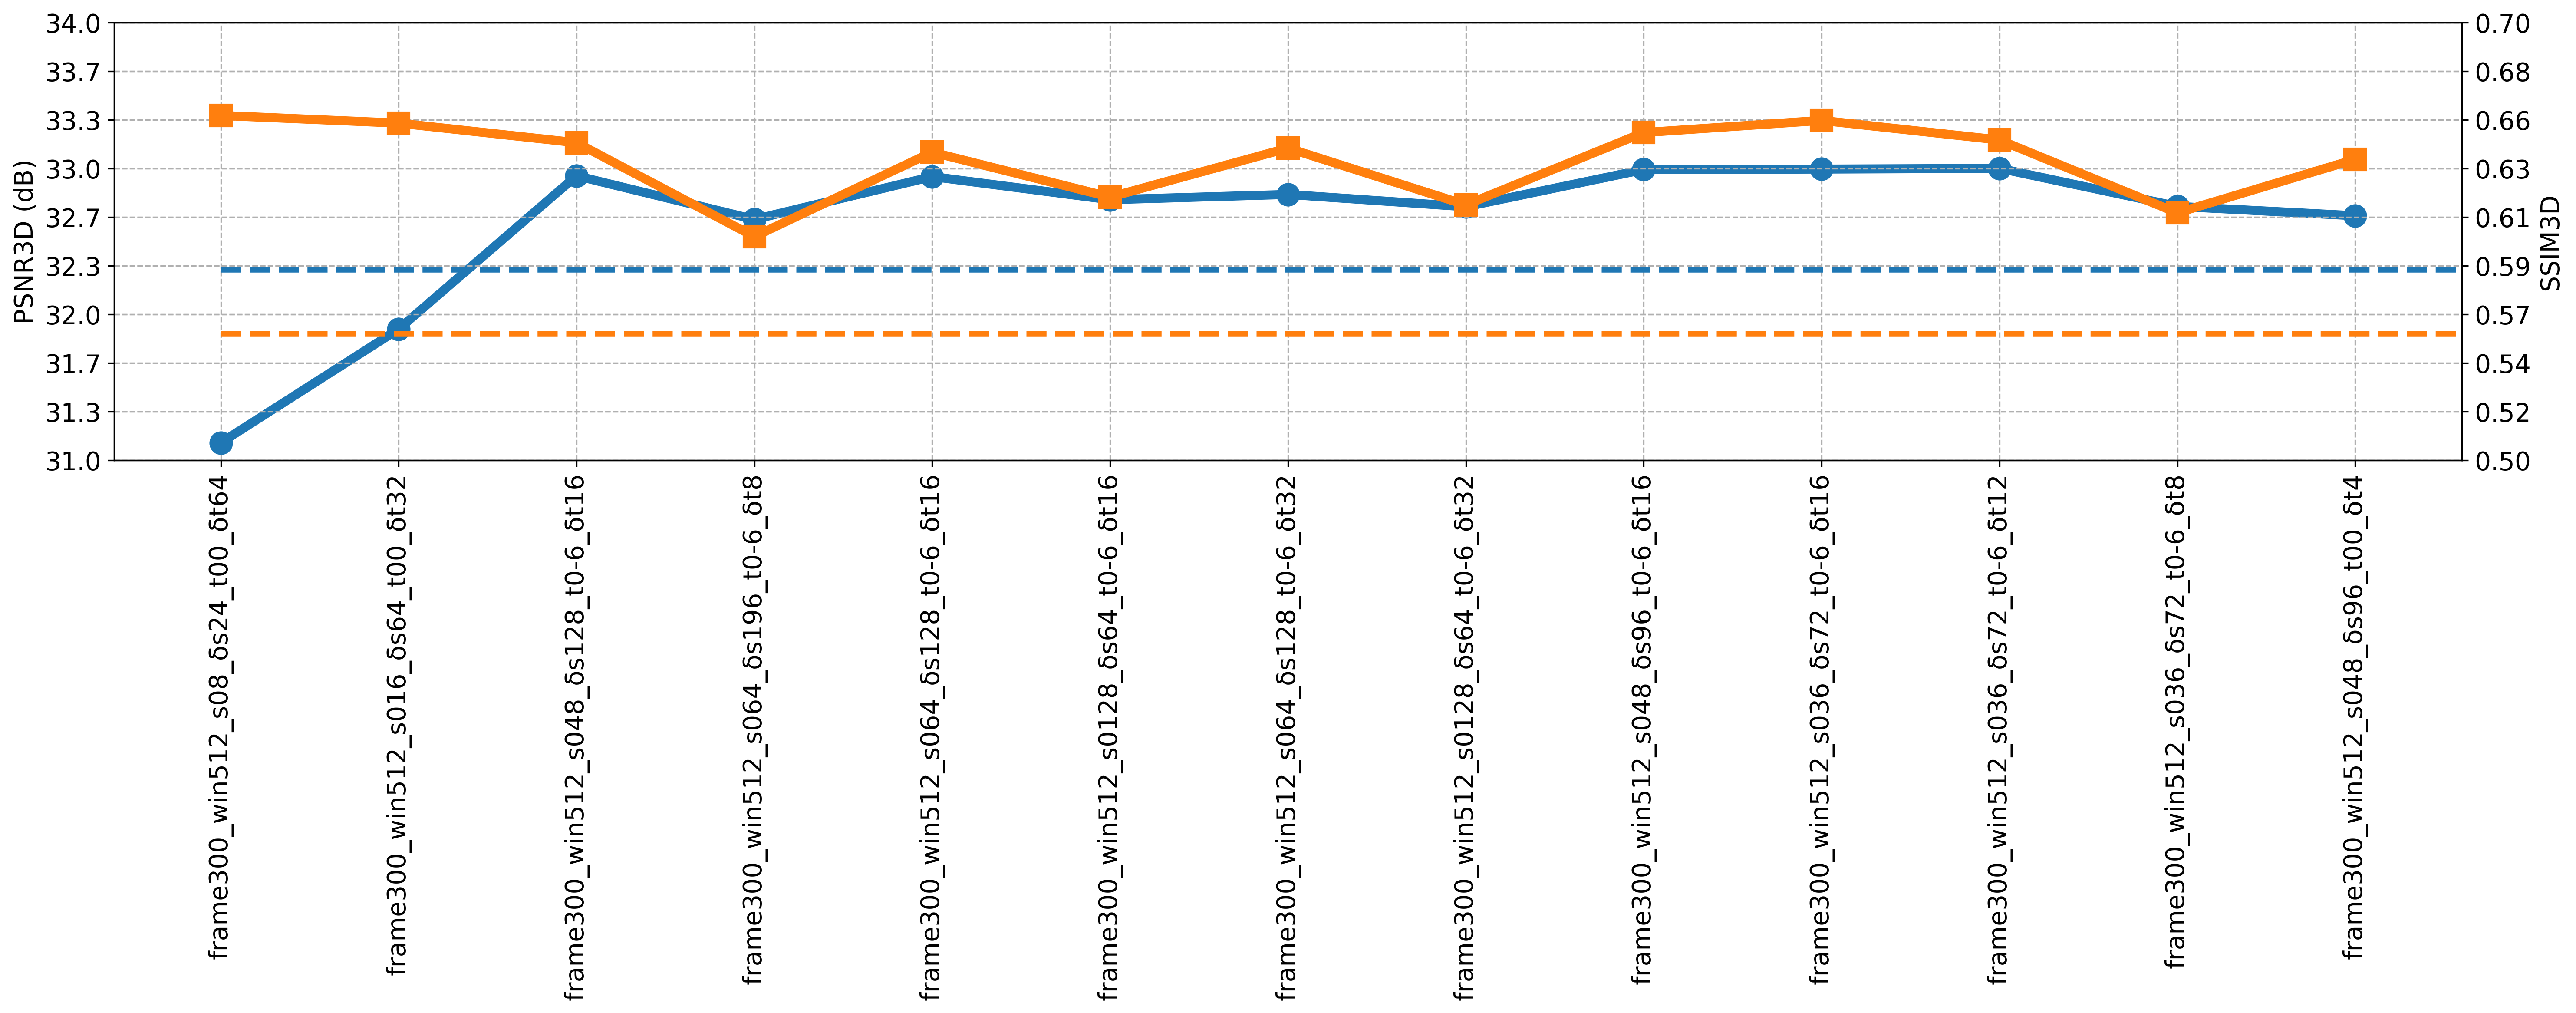

Max PSNR= 33.00 Max SSIM= 0.66


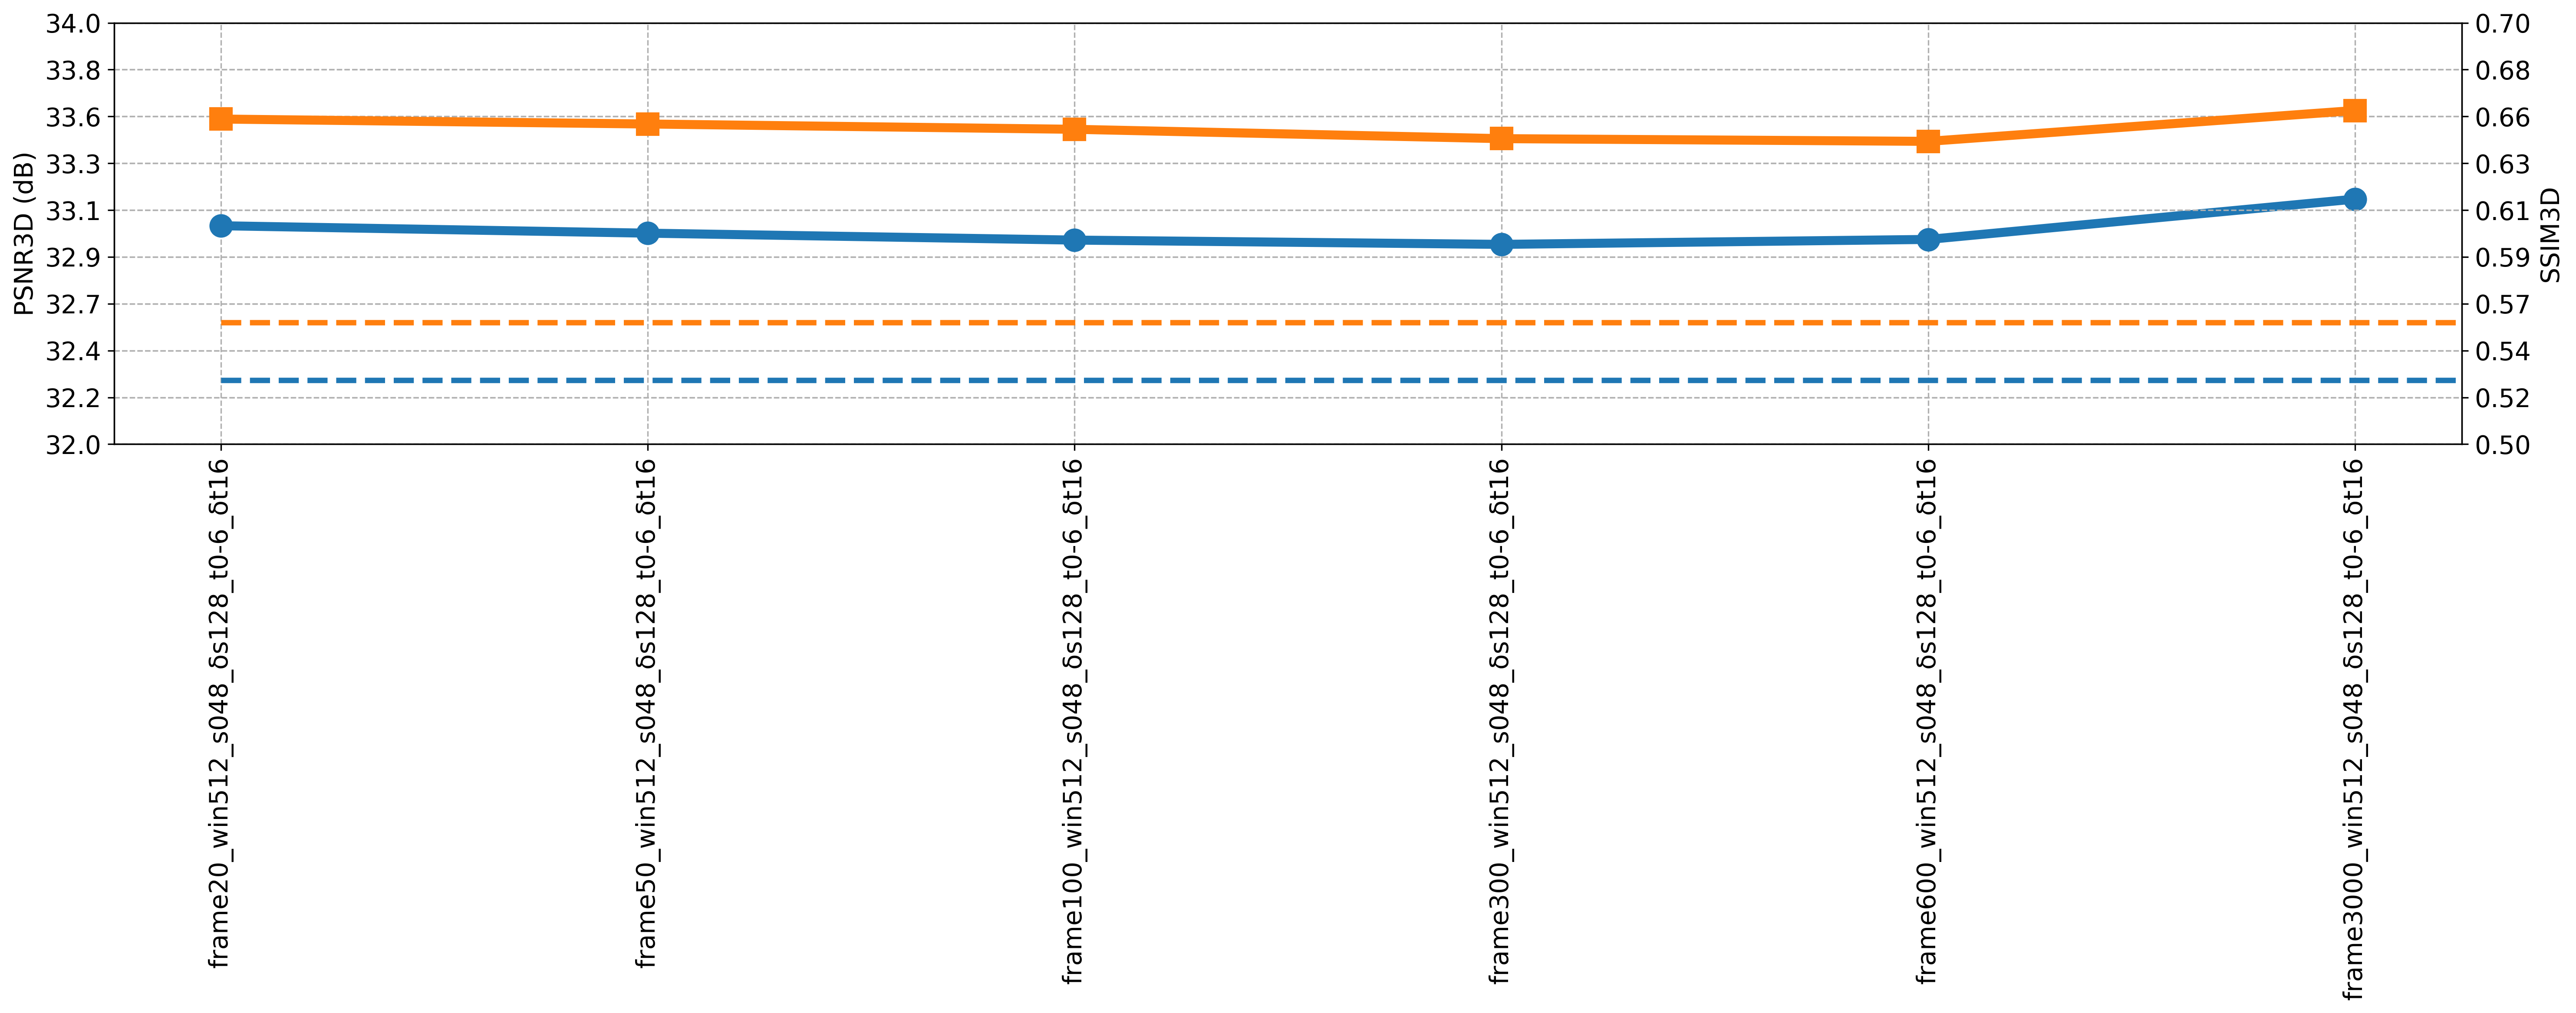

Max PSNR= 33.16 Max SSIM= 0.66


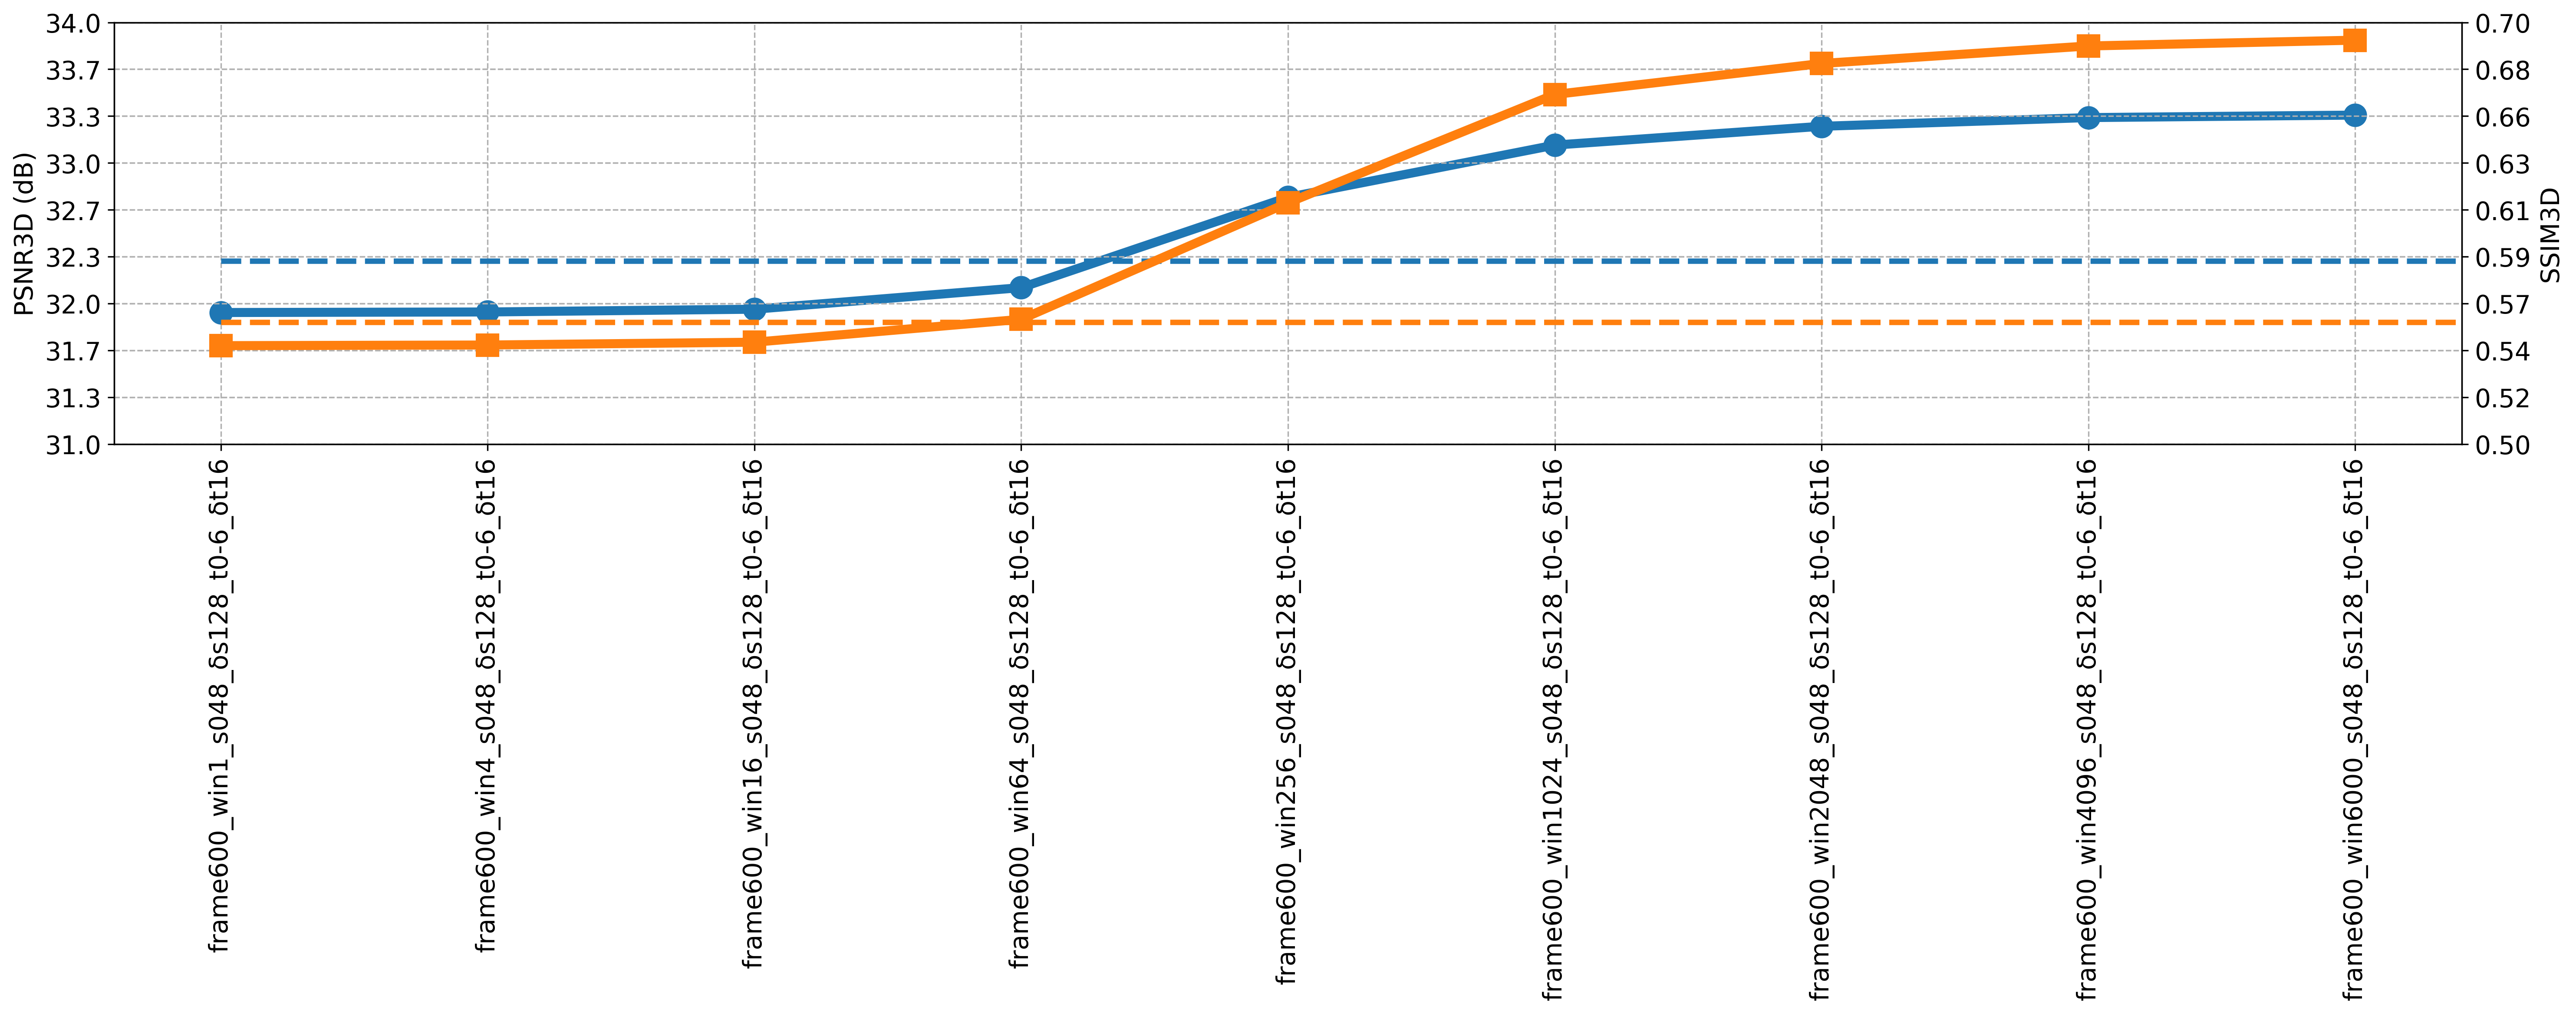

Max PSNR= 33.34 Max SSIM= 0.69


In [4]:
plot("dct_synthetic_metrics_weights.csv")
plot("dct_synthetic_metrics_frames.csv")
plot("dct_synthetic_metrics_avgs.csv")